# NBRA (step3) workflow for CP2K/Libra made simple, and (hopefully) more accurate

In this tutorial, I am going to show how the NBRA calculations (time-overlap, vibronic Hamiltonian, etc.) can be done using the outputs of the TD-DFT calculations in CP2K. First, I remind how the relevant information can be parsed from the output files. Second, I will show the implementation of workflow. Third, I will show how to use one of the Libra's modules to do this calculations and how to control the truncation of the Slated determinants. 


## Table of contents
<a name="toc"></a>
1. [Extracting TD-DFT data from CP2K log files](#1)

2. [Implementing the workflow](#2)

3. [Libra implementation](#3)

4. [Libra implementation - with active space truncation](#4)

5. [Checking consistency and approximations](#5)
  
   

### A. Learning objectives

* To extract the key infromation from the output file of CP2K calculations (energies, CI vectors, etc.)
* Understand the indexing conventions for various variables and properties
* To automate the calculations of the CI time-overlaps, adiabatic Hamiltonians, and adiabatic vibronic Hamiltonians using CP2K
* To use the active space in CP2K/Libra workflow to reduce computational expenses 


### B. Use cases

* computing CI wavefunction time-overlaps with CP2K
* define Libra/CP2K interface Hamiltonian
* computing many-body (TD-DFT) NACs

### C. Functions

- `libra_py`
  - `citools`
    - `ci`
      - [`overlap`](#overlap-1)
  - `orthogonalizations`
    - [`lowdin_inverse_sqrt`](#lowdin_inverse_sqrt-1)
  - `packages`
    - `cp2k`
      - `methods`
        - [`cp2k_compute_adi`](#cp2k_compute_adi-1)
        - [`read_cp2k_tddfpt_log_file`](#read_cp2k_tddfpt_log_file-1)


In [1]:
import os, time, copy, sys
import numpy as np
import scipy.sparse as sp

from libra_py import units
from libra_py import data_conv
import libra_py.packages.cp2k.methods as CP2K_methods
import libra_py.citools.ci as ci
import libra_py.orthogonalizations as ortho
from liblibra_core import *

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

Before starting, please unpack the data files:

In [2]:
#!tar -xf c20.tar.bz2

## 1. Extracting TD-DFT data from CP2K log files 
<a name="1"></a>
[Back to TOC](#toc)

Let's see how to extract the key information from excited state calculations from CK2K log files. 

This is done with the help of the `CP2K_methods.read_cp2k_tddfpt_log_file` function, which is recently revised, so many previous workflows (prior to **3/23/2026** may break down and are now considered obsolete!)

The function returns the general info with the key numbers, and the list of data elements - packaged in the same way as MOPAC/INDO-CI or DFTB+/TD-DFTB calculations in the recently added workflows, so we can take advantage of the recently added generalized workflows.
<a name="read_cp2k_tddfpt_log_file-1"></a>

In [3]:
help(CP2K_methods.read_cp2k_tddfpt_log_file)

Help on function read_cp2k_tddfpt_log_file in module libra_py.packages.cp2k.methods:

read_cp2k_tddfpt_log_file(params)
    Parse a CP2K TD-DFPT log file and extract excitation energies and CI expansion data.
    
    This function reads the output of a CP2K Time-Dependent Density Functional
    Perturbation Theory (TD-DFPT) calculation and reconstructs the excited-state
    wavefunctions in terms of single-particle (Kohn–Sham) excitations.
    
    In CP2K TD-DFPT, each excited state is represented as a linear combination of
    single excitations (Slater determinants) of the form:
    
        |Ψ_I⟩ = Σ_{i→a} C_{i→a}^{(I)} |Φ_i^a⟩
    
    where:
        - i denotes an occupied orbital
        - a denotes a virtual (unoccupied) orbital
        - C_{i→a}^{(I)} are CI-like expansion coefficients
        - |Φ_i^a⟩ is a singly-excited Slater determinant
    
    The function extracts:
        1. Excitation energies for each TD-DFPT state
        2. CI basis configurations (orbital transi

In [4]:
params_tddft = {'number_of_states': 10, 
                'tolerance': 0.01, 
                'logfile_name': 'c20/small_all_logfiles/step_1000.log', 
                'isUKS': False, 
                }
info, data = CP2K_methods.read_cp2k_tddfpt_log_file(params_tddft)

In [5]:
print(info)

{'nocc': 40, 'nelec': 80, 'nao': 100, 'nmo': 100, 'nci': 10, 'min_occ': 27, 'max_occ': 40, 'min_vir': 41, 'max_vir': 50, 'nact': 100, 'actual_orbital_space': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]}


The first argument of the `data` that was just extracted contains the excited states energies in eV.

In [6]:
data[0]

[0.03484583440520378,
 0.03971335121825733,
 0.04510639079783911,
 0.06704127007460219,
 0.075030686119584,
 0.07838006688471574,
 0.0878857814854287,
 0.08973870861048841,
 0.09245635956047187,
 0.10076586674506635]

The second output contains the excited states configurations. Its length is `number_of_states` and each element of that contain a list which is formed from one or multiple lists, each representing a single-particle excitation. For example:

In [7]:
data[1]

[[[40, 41], [40, 42], [40, 46], [40, 45], [40, 43]],
 [[40, 42],
  [40, 41],
  [40, 45],
  [40, 44],
  [40, 46],
  [39, 47],
  [40, 43],
  [35, 47]],
 [[40, 43],
  [40, 44],
  [40, 45],
  [40, 46],
  [40, 41],
  [38, 47],
  [40, 42],
  [38, 49],
  [37, 47]],
 [[40, 46], [40, 44], [40, 41], [40, 45], [40, 42], [38, 48], [39, 49]],
 [[40, 45],
  [40, 44],
  [40, 42],
  [37, 47],
  [40, 41],
  [27, 41],
  [35, 48],
  [40, 46],
  [39, 41],
  [35, 47],
  [38, 49],
  [28, 43],
  [37, 50]],
 [[40, 44],
  [40, 45],
  [40, 46],
  [40, 43],
  [39, 42],
  [37, 47],
  [37, 48],
  [38, 47],
  [38, 48],
  [39, 41],
  [40, 41],
  [35, 47],
  [40, 42],
  [36, 47],
  [35, 49],
  [36, 49],
  [38, 43],
  [29, 42],
  [28, 42],
  [39, 49],
  [27, 43],
  [39, 50]],
 [[38, 41],
  [39, 42],
  [39, 41],
  [40, 48],
  [39, 43],
  [38, 43],
  [40, 49],
  [40, 44],
  [40, 45],
  [37, 42],
  [39, 46],
  [35, 41]],
 [[39, 42],
  [38, 41],
  [39, 41],
  [38, 43],
  [39, 43],
  [40, 48],
  [38, 42],
  [40, 45],
  [36

The third element of the `data` variable contains the configuration interaction coefficients related to each single-particle excitation in each excited states.

In [8]:
data[2]

[[-0.96147, -0.194763, -0.115153, 0.088626, 0.075204],
 [0.960202,
  -0.194109,
  0.110211,
  0.079108,
  0.060789,
  0.044997,
  -0.044391,
  0.039318],
 [0.967931,
  0.190762,
  -0.05962,
  0.055474,
  0.054349,
  -0.045004,
  0.044214,
  -0.040568,
  -0.03551],
 [-0.938364, 0.298847, 0.085971, -0.067277, 0.056447, -0.039076, 0.032172],
 [0.884234,
  0.379124,
  -0.107507,
  0.089139,
  0.088453,
  0.08007,
  0.076039,
  0.059598,
  0.053901,
  -0.046841,
  -0.040992,
  -0.039555,
  -0.03662],
 [0.811361,
  -0.369942,
  0.283345,
  -0.178054,
  -0.109896,
  0.089769,
  0.081187,
  0.073784,
  0.069974,
  -0.066438,
  -0.06244,
  0.058566,
  -0.058208,
  0.052262,
  0.046262,
  0.045013,
  -0.044881,
  -0.041053,
  -0.038933,
  0.038009,
  0.033932,
  0.033797],
 [-0.772549,
  0.476316,
  0.366805,
  0.097439,
  -0.093085,
  0.05717,
  0.051288,
  0.04991,
  -0.049015,
  0.03834,
  0.03787,
  -0.03472],
 [0.613421,
  0.562207,
  0.377445,
  0.257406,
  0.175308,
  -0.119442,
  0.09278

In [9]:
sample_matrix = sp.load_npz('c20/small_res/St_ks_1000.npz')

In [10]:
sample_matrix.shape

(76, 76)

In [11]:
#params['lowest_orbital'] = 17# 20 Occupied orbitals
#params['highest_orbital'] = 54 # 20 Unoccupied orbitals
54 - 17 + 1

38

In [12]:
lowest_orbital = 17
ndim = sample_matrix.shape[0] // 2
actual_orbital_space = list(range(lowest_orbital, lowest_orbital + ndim ))

print(actual_orbital_space)

[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


## 2. Implementing the workflow
<a name="2"></a>[Back to TOC](#toc)
<a name="overlap-1"></a>

In the implementation, we assume that the wavefunctions we read may not be exactly orthonormal because of the finite precision of the coefficients printed by the cp2k in the files and because of various kinds of truncation. So, before computing time-overlaps, we apply Lowdin orthonormalization of the CI wavefucntions. In principle, we don't work directly with the wavefunction, but we introduce the corresponding transformations of the "raw" time-overlaps.

Lowdin transformation is realized via the function:
<a name="lowdin_inverse_sqrt-1"></a>

In [13]:
help(ortho.lowdin_inverse_sqrt)

Help on function lowdin_inverse_sqrt in module libra_py.orthogonalizations:

lowdin_inverse_sqrt(S, thresh=1e-10)
    Compute the inverse square root of an overlap matrix using Löwdin symmetric orthogonalization.
    
    This function evaluates S^{-1/2} via eigenvalue decomposition:
        S = U diag(λ) U†  →  S^{-1/2} = U diag(λ^{-1/2}) U†
    
    Small eigenvalues below a specified threshold are treated as zero to ensure
    numerical stability and avoid divergences. The input matrix is explicitly
    symmetrized to enforce Hermiticity before diagonalization.
    
    Parameters
    ----------
    S : array_like (N, N)
        Real or complex overlap matrix. It is assumed to be Hermitian
        (or close to Hermitian within numerical precision).
    thresh : float, optional
        Eigenvalue cutoff below which eigenvalues are treated as zero.
        This prevents instabilities due to near-linear dependencies.
        Default is 1e-10.
    
    Returns
    -------
    S_inv_sqrt

In [14]:
class tmp:
    pass

def cp2k_compute_adi(q, params, full_id):
    """
    Compute adiabatic electronic properties and derivative couplings
    for a single trajectory using CP2K TDDFPT outputs and CI overlap analysis.

    This function performs a single electronic structure evaluation step in a
    trajectory-based nonadiabatic dynamics simulation. It constructs adiabatic
    and vibronic Hamiltonians, evaluates time-overlap matrices between electronic
    states at consecutive time steps, and estimates derivative couplings using
    finite-difference time overlaps.

    The implementation assumes that CP2K TDDFPT calculations have already been
    executed externally and that all required output files (log files and MO
    overlap matrices) are available.

    Parameters
    ----------
    q : MATRIX
        Nuclear coordinates for all trajectories.
        Shape: (3*N_atoms, N_trajectories)
        Units: Bohr

    params : dict
        Dictionary containing simulation parameters and trajectory-specific data.

        Required keys
        -------------
        nstates : int
            Number of adiabatic electronic states.

        logfile_name : str
            Path to CP2K TDDFPT log file.

        time_overlap_filename : str
            Path to sparse MO overlap matrix file (.npz format).

        atom_labels : list of str
            Atomic symbols (currently not used directly in this function).

        lowest_orbital : int
            Lowest orbital index included in the overlap matrix (1-based indexing).

        Optional keys
        -------------
        dt : float, default=41.0
            Nuclear time step (atomic units).

        ci_threshold : float, default=1e-3
            Threshold for CI coefficient truncation.

        nelec_act_space : int, optional
            Number of electrons in the active space. If not provided,
            the full orbital space is used.

        working_directory_prefix : str, default="wd"
            Prefix for trajectory-specific working directories.

        Internal state (updated in-place)
        --------------------------------
        data_prev : dict
            Previous CI/electronic structure data per trajectory.

        coordinates_prev : dict
            Previous nuclear coordinates per trajectory.

        is_first_time : dict
            Flags indicating first step per trajectory.

        act_state : dict
            Active electronic state per trajectory (currently only used in commented sections).

    full_id : int or object
        Encoded trajectory identifier. The last element corresponds to `itraj`.

    Returns
    -------
    obj : tmp
        Container object with computed electronic properties.

        Attributes
        ----------
        ham_adi : CMATRIX (nstates, nstates)
            Adiabatic Hamiltonian (diagonal energies).

        hvib_adi : CMATRIX (nstates, nstates)
            Vibronic Hamiltonian including derivative coupling terms:
                H_ij = E_i δ_ij - i d_ij

        time_overlap_adi : CMATRIX (nstates, nstates)
            Time-overlap matrix:
                S_ij = <Ψ_i(t) | Ψ_j(t + dt)>

        basis_transform : CMATRIX (nstates, nstates)
            Basis transformation matrix (identity).

        nac_adi : CMATRIX (nstates, nstates)
            Placeholder for nonadiabatic couplings (currently unused).

        d1ham_adi : CMATRIXList (length = ndof)
            Derivatives of Hamiltonian w.r.t. nuclear coordinates
            (currently zero-filled; forces code is commented out).

        dc1_adi : CMATRIXList (length = ndof)
            Derivative couplings per nuclear degree of freedom
            (currently zero-filled unless NACV block is enabled).

    Notes
    -----
    - Ground state energy is set to zero; excited-state energies are averaged
      between previous and current time steps.

    - Time-overlaps are computed at the CI level using molecular orbital overlaps
      and CI coefficients from consecutive steps.

    - Derivative couplings are approximated via:
          d_ij = (S_ij - S_ji) / (2 * dt)

      and included in the vibronic Hamiltonian as:
          H_ij = -i * d_ij  (off-diagonal terms)

    - Active space selection:
        * If `nelec_act_space` is None → full orbital space is used.
        * Otherwise, a truncated space around HOMO is constructed.

    - The function assumes:
        * Closed-shell (restricted) calculations (`isUKS=False`)
        * Real-valued CI overlaps

    - NACVs (analytic derivative couplings) and forces are currently disabled
      but can be enabled via the commented sections.

    - All trajectory-specific data is stored in `params` to support
      multi-trajectory simulations.

    Limitations
    -----------
    - No phase correction is applied to CI states.
    - Overlap matrix is assumed to be correctly aligned (no orbital reordering).
    - No error handling for missing files (e.g., overlap matrix).
    - Vibronic Hamiltonian neglects diagonal derivative terms.

    Example
    -------
    >>> obj = cp2k_compute_adi(q, params, full_id)
    >>> print(obj.ham_adi)
    >>> print(obj.time_overlap_adi)
    >>> print(obj.hvib_adi)
    """
    
    # ================= Decode trajectory index =================
    Id = Cpp2Py(full_id)
    itraj = Id[-1]

    # ================= Extract coordinates =================
    coords = q.col(itraj)
    coordinates = data_conv.MATRIX2nparray(coords, float)

    ndof = coords.num_of_rows
    nat = ndof // 3

    # ================= Safe param access =================
    params.setdefault("MO_prev", {})
    params.setdefault("data_prev", {})
    params.setdefault("coordinates_prev", {})
    params.setdefault("s_ci_inv_prev", {})
    params.setdefault("is_first_time", {})
    params.setdefault("act_state", {})

    is_first_time = params["is_first_time"].get(itraj, True)
    act_state = params["act_state"].get(itraj, 0)
    nelec_act_space = params.get("nelec_act_space", None)
    
    lowest_orbital = params["lowest_orbital"]

    # ================= Read parameters =================
    dt = float(params.get("dt", 41.0))
    atom_labels = params["atom_labels"]

    wd_prefix = params.get("working_directory_prefix", "wd")
    wd = f"{wd_prefix}_itraj{itraj}"

    # ================= Run CP2K =================
    # Currently - we just take the external files
    
    # ================= Previous coordinates =================
    if is_first_time:
        coordinates_prev = coordinates.copy()
    else:
        coordinates_prev = params["coordinates_prev"].get(itraj, coordinates).copy()

    # ================= Read electronic structure =================
    nstates = params["nstates"]

    read_params = {
        "number_of_states": nstates,
        "logfile_name": params["logfile_name"],
        "ci_threshold": params.get("ci_threshold", 0.001),
        'isUKS': False
    }
    info, data_curr = CP2K_methods.read_cp2k_tddfpt_log_file(read_params)    
    #print(F"info = {info}")
    
    
    # ================= Previous electronic data =================
    if is_first_time:
        data_prev = copy.deepcopy(data_curr)
    else:
        data_prev = params["data_prev"].get(itraj, data_curr)

    # ================= Build object =================
    obj = tmp()
    obj.ham_adi = CMATRIX(nstates, nstates)
    obj.nac_adi = CMATRIX(nstates, nstates)
    obj.hvib_adi = CMATRIX(nstates, nstates)
    obj.basis_transform = CMATRIX(nstates, nstates)
    obj.time_overlap_adi = CMATRIX(nstates, nstates)
    obj.overlap_adi = CMATRIX(nstates, nstates)

    # ================= Compute overlaps =================
    
    st_mo = sp.load_npz(params["time_overlap_filename"]).todense()
    s_mo = sp.load_npz(params["overlap_filename"]).todense()
    
    ndim = st_mo.shape[0] // 2
    print(F"ndim = {ndim}")
    orbital_space = list(range(lowest_orbital, lowest_orbital + ndim  ))
    
    #================= Construct active space ==================    
    active_space = None
    if nelec_act_space is None:
        active_space = list(orbital_space)
    else:
        min_indx = info["nocc"] - nelec_act_space//2 + 1
        if min_indx > info["min_occ"]:
            min_elec = ((info["nocc"] - info["min_occ"]) + 1 )*2
            raise ValueError(f"The `nelec_act_space` should be at least { min_elec }")
        active_space = list(range(min_indx, info["max_vir"]+1))
        
    #================= Compute CI time-overlaps =============
    # lowest_orbital = homo_indx - nocc => nocc = homo_indx - lowest_orbital
    # highest_orbital = homo_indx + nvirt => nvirt = highest_orbital - homo_indx 
    # The actual number of electrons is determined by the active_space if 
    # it is not None!
    highest_orbital = lowest_orbital + ndim - 1
    ovlp_params = {"homo_indx":info["nocc"],
                   "nocc":info["nocc"] - lowest_orbital,
                   "nvirt": highest_orbital - info["nocc"],
                   "nelec": (info["nocc"] - lowest_orbital + 1) * 2, 
                   "nstates":nstates,
                   "active_space":active_space,
                   "orbital_space": orbital_space
                   }
    
    #print(F"orbital_space of the overlap matrix (the 1-based indices of orbitals): {orbital_space}")
    #print("active_space = ", active_space)
    
    st_ci = ci.overlap(st_mo, data_prev, data_curr, ovlp_params)
    s_ci = ci.overlap(s_mo, data_curr, data_curr, ovlp_params)
    
    s_ci_inv_curr = ortho.lowdin_inverse_sqrt(s_ci)
    s_ci_inv_prev = None
    if is_first_time:
        s_ci_inv_prev = copy.deepcopy(s_ci_inv_curr)
    else:
        s_ci_inv_prev = params["s_ci_inv_prev"].get(itraj, s_ci_inv_curr)
    
    s_ci = s_ci_inv_curr @ s_ci @ s_ci_inv_curr
    st_ci = s_ci_inv_prev @ st_ci @ s_ci_inv_curr
    
    
    # ================= Populate Hamiltonian =================
    for i in range(nstates):
        energy = 0.0 if i == 0 else 0.5 * (
            data_prev[0][i - 1] + data_curr[0][i - 1]
        )

        obj.ham_adi.set(i, i, energy)
        obj.hvib_adi.set(i, i, energy)
        obj.basis_transform.set(i, i, 1.0)

        for j in range(nstates):
            obj.time_overlap_adi.set(i, j, float(st_ci[i, j]))
            obj.overlap_adi.set(i,  j, float(s_ci[i,j]) )

    # ================== Forces ===============================
    obj.d1ham_adi = CMATRIXList()
    for idof in range(ndof):
        obj.d1ham_adi.append(CMATRIX(nstates, nstates))

    #for iatom in range(nat):
    #    obj.d1ham_adi[3 * iatom + 0].set(act_state, act_state, -forces[0, iatom] * (1.0 + 0.0j))
    #    obj.d1ham_adi[3 * iatom + 1].set(act_state, act_state, -forces[1, iatom] * (1.0 + 0.0j))
    #    obj.d1ham_adi[3 * iatom + 2].set(act_state, act_state, -forces[2, iatom] * (1.0 + 0.0j))

    # ================= Derivative couplings ====================
    obj.dc1_adi = CMATRIXList()
    for idof in range(ndof):
        obj.dc1_adi.append(CMATRIX(nstates, nstates))

    #if os.path.exists(f"{wd}/NACV.DAT"):
    #    nacv = read_nacv(f"{wd}/NACV.DAT")
    #    for iatom in range(nat):
    #        for i in range(nstates):
    #            for j in range(nstates):
    #                obj.dc1_adi[3 * iatom + 0].set(i, j, nacv[i,j,0,iatom] * (1.0 + 0.0j))
    #                obj.dc1_adi[3 * iatom + 1].set(i, j, nacv[i,j,1,iatom] * (1.0 + 0.0j))
    #                obj.dc1_adi[3 * iatom + 2].set(i, j, nacv[i,j,2,iatom] * (1.0 + 0.0j))

    # ================= Compute derivative couplings =================
    for i in range(nstates):
        for j in range(i + 1, nstates):
            dij = ( obj.time_overlap_adi.get(i, j) - obj.time_overlap_adi.get(j, i) ) / (2.0 * dt)
            obj.hvib_adi.set(i, j, -1j * dij)
            obj.hvib_adi.set(j, i, +1j * dij)            
            
    # ================= Store state =================
    #params["MO_prev"][itraj] = MO_curr.copy()
    params["data_prev"][itraj] = copy.deepcopy(data_curr)
    params["s_ci_inv_prev"][itraj] = copy.deepcopy(s_ci_inv_curr)
    params["coordinates_prev"][itraj] = coordinates.copy()
    params["is_first_time"][itraj] = False

    return obj


In [15]:
print(1)

1


In [16]:
labels, q = CP2K_methods.read_trajectory_xyz_file("c20/C20-md-aligned.xyz", 0)
print(labels)
print(q)

params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "nelec_act_space":None,
          "ci_threshold":0.01,
          "lowest_orbital": 17,          
          "nstates": 10,
          "nelec_act_space":None,              
          "is_first_time":{0:True},
          "act_state":{0:1},
         }
print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = CP2K_methods.read_trajectory_xyz_file("c20/C20-md-aligned.xyz", i)
    params["timestep"] = i
    params["logfile_name"] = F"c20/small_all_logfiles/step_{1000+i}.log"
    params["time_overlap_filename"] = F"c20/small_res/St_ks_{1000+i}.npz"
    params["overlap_filename"] = F"c20/small_res/S_ks_{1000+i}.npz"
    
    obj = cp2k_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")
    obj.overlap_adi.real().show_matrix(F"{res}/s_adi_{i}.txt")


['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
{'atom_labels': ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'], 'timestep': 0, 'dt': 41.339396444811904, 'nelec_act_space': None, 'ci_threshold': 0.01, 'lowest_orbital': 17, 'nstates': 10, 'is_first_time': {0: True}, 'act_state': {0: 1}}
======== Iteration 0 ==============
ndim = 38


/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/citools/slatdet.py:351: ComplexWarning: Casting complex values to real discards the imaginary part
  S_AB[i, j] = np.linalg.det(S_a) * np.linalg.det(S_b) * ph_A[i] * ph_B[j]
/tmp/ipykernel_282201/569281880.py:285: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.time_overlap_adi.set(i, j, float(st_ci[i, j]))
/tmp/ipykernel_282201/569281880.py:286: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.overlap_adi.set(i,  j, float(s_ci[i,j]) )


======== Iteration 1 ==============
ndim = 38
======== Iteration 2 ==============
ndim = 38
======== Iteration 3 ==============
ndim = 38
======== Iteration 4 ==============
ndim = 38


Checking the determinant of the time-overlap matrices depending on the size of the set of electronic states included in this space:

In [17]:
istep = 0
data_path = "results"
st = np.loadtxt(F"{data_path}/st_adi_{istep}.txt")
NSTATES = st.shape[0]
print(F"NSTATES = {NSTATES}")

NSTEPS = 5
NSTATES = 10
numpy_st_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )

for istep in range(NSTEPS):
    numpy_st_adi[istep, :, :] = np.loadtxt(F"{data_path}/st_adi_{istep}.txt")

for nact_st in range(NSTATES):     
    min_val = np.min( np.abs( np.linalg.det(numpy_st_adi[:,:nact_st,:nact_st]) ) ) 
    print(F"nact_st = {nact_st}, min_val = {min_val}")

NSTATES = 10
nact_st = 0, min_val = 1.0
nact_st = 1, min_val = 0.99864647
nact_st = 2, min_val = 0.9921885451629335
nact_st = 3, min_val = 0.9709244864109388
nact_st = 4, min_val = 0.965465587597181
nact_st = 5, min_val = 0.8079736225397259
nact_st = 6, min_val = 0.42375471619412775
nact_st = 7, min_val = 0.9770436721151491
nact_st = 8, min_val = 0.23819281406781082
nact_st = 9, min_val = 0.8057737854004969


As we can see - some subsets of states may be more favorable. For instance, having 6 states in the basis leads to a relatively small minimal value of the determinant of about 0.42, which may be because that state 6 may be switching with state 7 which is not included in this subset. However, as the state 7 is included, the minimal determinant suddenly goes up to 0.977, which indicates the completeness (well, self-containedness) of such basis space. 

## 3. Libra implementation
<a name="3"></a>[Back to TOC](#toc)

Now, we are going to use the cleaned-up and slightly revised version of the above workflow - the one implemented in Libra
<a name="cp2k_compute_adi-1"></a>

In [18]:
help(CP2K_methods.cp2k_compute_adi)

Help on function cp2k_compute_adi in module libra_py.packages.cp2k.methods:

cp2k_compute_adi(q, params, full_id)
    Compute adiabatic electronic properties and derivative couplings
    for a single trajectory using CP2K TDDFPT outputs and CI overlap analysis.
    
    This function performs a single electronic structure evaluation step in a
    trajectory-based nonadiabatic dynamics simulation. It constructs adiabatic
    and vibronic Hamiltonians, evaluates time-overlap matrices between electronic
    states at consecutive time steps, and estimates derivative couplings using
    finite-difference time overlaps.
    
    The implementation assumes that CP2K TDDFPT calculations have already been
    executed externally and that all required output files (log files and MO
    overlap matrices) are available.
    
    Parameters
    ----------
    q : MATRIX
        Nuclear coordinates for all trajectories.
        Shape: (3*N_atoms, N_trajectories)
        Units: Bohr
    
    params :

In [19]:
labels, q = CP2K_methods.read_trajectory_xyz_file("c20/C20-md-aligned.xyz", 0)
print(labels)
print(q)

params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "nelec_act_space":None,
          "ci_threshold":0.01,
          "lowest_orbital": 17,          
          "nstates": 10,
          "nelec_act_space":None,              
          "is_first_time":{0:True},
          "act_state":{0:1},
         }
print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results2"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = CP2K_methods.read_trajectory_xyz_file("c20/C20-md-aligned.xyz", i)
    params["timestep"] = i
    params["logfile_name"] = F"c20/small_all_logfiles/step_{1000+i}.log"
    params["time_overlap_filename"] = F"c20/small_res/St_ks_{1000+i}.npz"
    params["overlap_filename"] = F"c20/small_res/S_ks_{1000+i}.npz"
    
    obj = CP2K_methods.cp2k_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")
    obj.overlap_adi.real().show_matrix(F"{res}/s_adi_{i}.txt")

['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
{'atom_labels': ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'], 'timestep': 0, 'dt': 41.339396444811904, 'nelec_act_space': None, 'ci_threshold': 0.01, 'lowest_orbital': 17, 'nstates': 10, 'is_first_time': {0: True}, 'act_state': {0: 1}}
======== Iteration 0 ==============


/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/packages/cp2k/methods.py:2932: ComplexWarning: Casting complex values to real discards the imaginary part
  st_mo = st_mo.astype(np.float64, copy=False)
/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/packages/cp2k/methods.py:3007: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.time_overlap_adi.set(i, j, float(st_ci[i, j]))
/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/packages/cp2k/methods.py:3008: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.overlap_adi.set(i,  j, float(s_ci[i,j]) )


======== Iteration 1 ==============
======== Iteration 2 ==============
======== Iteration 3 ==============
======== Iteration 4 ==============


## 4. Libra implementation - with active space truncation
<a name="4"></a>[Back to TOC](#toc)

Following the [MOPAC's tutorial](https://github.com/compchem-cybertraining/Tutorials_Libra/tree/master/11_program_specific_methods/5_mopac_methods/2_using_active_spaces), we can introduce the truncation of the Slater determinants in the underlying constructions:


Reminder: 

All it takes to do is to define the active space of orbitals. For user convenience, the current approach is to define the active space internally - it includes all virtual orbitals and a number of occupied orbitals that is controlled by `nelec_act_space` keyword. Setting it to 2, for instance, will include only the HOMO orbital in the active space, 4 - will also add HOMO-1, and so on.

This number should be larger than `(nocc - min_occ + 1 )*2` 

For instance, for the CAS(6,3), the number of electrons in determinants should be at least `(8 - 6 + 1)*2 = 6`. Otherwise, there will be not enough flexibility to create all possible SDs that can be encountered in the CI expansion.

In [20]:
labels, q = CP2K_methods.read_trajectory_xyz_file("c20/C20-md-aligned.xyz", 0)
print(labels)
print(q)

params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "nelec_act_space":None,
          "ci_threshold":0.01,
          "lowest_orbital": 17,          
          "nstates": 10,
          "nelec_act_space":12,              
          "is_first_time":{0:True},
          "act_state":{0:1},
         }
print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results3"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = CP2K_methods.read_trajectory_xyz_file("c20/C20-md-aligned.xyz", i)
    params["timestep"] = i
    params["logfile_name"] = F"c20/small_all_logfiles/step_{1000+i}.log"
    params["time_overlap_filename"] = F"c20/small_res/St_ks_{1000+i}.npz"
    params["overlap_filename"] = F"c20/small_res/S_ks_{1000+i}.npz"
    
    obj = CP2K_methods.cp2k_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")
    obj.overlap_adi.real().show_matrix(F"{res}/s_adi_{i}.txt")

['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
{'atom_labels': ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'], 'timestep': 0, 'dt': 41.339396444811904, 'nelec_act_space': 12, 'ci_threshold': 0.01, 'lowest_orbital': 17, 'nstates': 10, 'is_first_time': {0: True}, 'act_state': {0: 1}}
======== Iteration 0 ==============
======== Iteration 1 ==============
======== Iteration 2 ==============
======== Iteration 3 ==============
======== Iteration 4 ==============


## 5. Checking consistency and approximations
<a name="5"></a>[Back to TOC](#toc)

Here, the difference between `results` and `results2` should be zero exactly as these are the same calculations, but just Jupyter vs. Libra implementations

The difference between `results` and `results3` should be small, but may be non-zero - here, we introduce the truncation of the Slater determinants

In [21]:
e1, e2 = [], []
for i in range(5):
    s = np.loadtxt(F"results/st_adi_{i}.txt")
    s2 = np.loadtxt(F"results2/st_adi_{i}.txt")
    s3 = np.loadtxt(F"results3/st_adi_{i}.txt")
    e1.append( np.max(np.abs(s2-s)))
    e2.append( np.max(np.abs(s3-s)))

In [22]:
print(e1, e2)

[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)] [np.float64(0.0006874500000000339), np.float64(0.0008286400000000471), np.float64(0.0006654799999999961), np.float64(0.0007846799999999821), np.float64(0.0007674399999999526)]


In [23]:
import matplotlib.pyplot as plt
%matplotlib inline

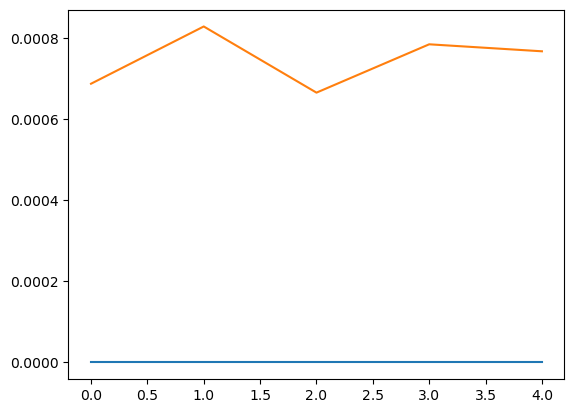

In [25]:
plt.plot(e1)
plt.plot(e2)
plt.show()